# NB09 — Hybrid Recommendation Model

A hybrid recommender combines signals from multiple model types to outperform any single model in coverage, cold-start handling, and accuracy.

## Strategy

Three hybrid strategies are implemented and compared:

| Strategy | How It Works | Handles Cold-Start? |
|---|---|---|
| **Weighted Blend** | Predicted ratings are combined as a weighted sum of individual model scores | Partial (content scores always available) |
| **Switching** | Routes each query to the best model for that user/item based on data availability | Yes — switches to content-based for cold users |
| **Meta-Learner (Stacking)** | Trains a Ridge regression on model predictions to learn optimal per-user-type weights | Yes — but requires training data for all sources |

## Signals Used

```
Content-Based  TF-IDF cosine sim (NB05)  ────────────────────────────┐
FunkSVD        latent factor dot product (NB07)  ─────────────────────┤
NeuMF          neural network predicted rating (NB08)  ───────────────► Hybrid Score
Bayesian Score quality popularity score (NB04)  ─────────────────────┘
```

The best hybrid is saved as the project's primary recommendation function.

## 1. Imports & Paths

In [1]:
import pathlib, pickle, time, warnings, sys
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT      = pathlib.Path('../../').resolve()
MODELS    = ROOT / 'models'
PROCESSED = ROOT / 'data_science' / 'processed'
MOVIELENS = ROOT / 'data' / 'movielens'

print("Root    :", ROOT)
print("Models  :", MODELS)

Root    : E:\Projects\Movies Recommendation Engine
Models  : E:\Projects\Movies Recommendation Engine\models


## 2. Load All Model Artefacts

In [4]:

import scipy.sparse as sp_mod  # already imported as sp, alias for clarity

# ── FunkSVD class stub — required to unpickle funksvd_model.pkl ───────────
class FunkSVD:
    """Biased MF with SGD — mirrors NB07 definition for pickle compatibility."""
    def __init__(self, n_factors=50, n_epochs=20, lr=0.005, reg=0.02, seed=42):
        self.k = n_factors; self.epochs = n_epochs
        self.lr = lr; self.reg = reg; self.seed = seed
    def predict(self, u: int, i: int) -> float:
        import numpy as _np
        pred = float(self.global_mean + self.bu[u] + self.bi[i]
                     + _np.dot(self.P[u], self.Q[i]))
        return float(_np.clip(pred, 0.5, 5.0))

# ── CF (NB06) ──────────────────────────────────────────────────────────────
user_item = sp.load_npz(MODELS / 'user_item_matrix.npz')
with open(MODELS / 'user_id_map.pkl',  'rb') as f: _u = pickle.load(f)
with open(MODELS / 'movie_id_map.pkl', 'rb') as f: _m = pickle.load(f)
user_id_map  = _u['user2idx']    # {userId  → row_index}
movie_id_map = _m['movie2idx']   # {movieId → col_index}
idx_to_movie = _m['idx2movie']   # {col_index → movieId}

# ── FunkSVD (NB07) ─────────────────────────────────────────────────────────
with open(MODELS / 'funksvd_model.pkl', 'rb') as f: funk = pickle.load(f)

# ── NeuMF / NCF (NB08) ─────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn

    with open(MODELS / 'ncf_config.pkl',    'rb') as f: ncf_cfg   = pickle.load(f)
    with open(MODELS / 'ncf_user_enc.pkl',  'rb') as f: user_enc  = pickle.load(f)
    with open(MODELS / 'ncf_movie_enc.pkl', 'rb') as f: movie_enc = pickle.load(f)

    # Re-instantiate model architecture (n_movies matches ncf_config.pkl key)
    class NeuMF(nn.Module):
        def __init__(self, n_users, n_movies, gmf_dim=32, mlp_dim=64,
                     mlp_layers=[128, 64, 32], dropout=0.2):
            super().__init__()
            self.gmf_user_emb = nn.Embedding(n_users, gmf_dim)
            self.gmf_item_emb = nn.Embedding(n_movies, gmf_dim)
            self.mlp_user_emb = nn.Embedding(n_users, mlp_dim)
            self.mlp_item_emb = nn.Embedding(n_movies, mlp_dim)
            mlp_in = mlp_dim * 2
            layers = []
            for out_size in mlp_layers:
                layers += [nn.Linear(mlp_in, out_size), nn.ReLU(), nn.Dropout(dropout)]
                mlp_in = out_size
            self.mlp_tower = nn.Sequential(*layers)
            self.output = nn.Linear(gmf_dim + mlp_layers[-1], 1)
        def forward(self, u, i):
            gmf_out = self.gmf_user_emb(u) * self.gmf_item_emb(i)
            mlp_out = self.mlp_tower(torch.cat([self.mlp_user_emb(u), self.mlp_item_emb(i)], dim=1))
            return 0.5 + 4.5 * torch.sigmoid(self.output(torch.cat([gmf_out, mlp_out], dim=1))).squeeze(1)

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ncf_model = NeuMF(**ncf_cfg).to(DEVICE)
    ncf_model.load_state_dict(torch.load(MODELS / 'ncf_model_weights.pt', map_location=DEVICE))
    ncf_model.eval()
    NCF_AVAILABLE = True
    print(f"NeuMF model loaded on {DEVICE}.")
except Exception as e:
    NCF_AVAILABLE = False
    print(f"NCF not available: {e}")

# ── Content-Based (NB05) ───────────────────────────────────────────────────
tfidf_matrix = sp.load_npz(MODELS / 'tfidf_matrix.npz')
with open(MODELS / 'title_to_idx.pkl', 'rb') as f: title_to_idx = pickle.load(f)

# ── Master movie table ─────────────────────────────────────────────────────
master   = pd.read_parquet(PROCESSED / 'master_movies.parquet',
                            columns=['tmdb_id','title','bayesian_score','tmdb_votes'])
links    = pd.read_csv(MOVIELENS / 'links.csv', usecols=['movieId','tmdbId'])
links    = links.dropna(subset=['tmdbId'])
links['tmdbId']  = links['tmdbId'].astype(int)
links['movieId'] = links['movieId'].astype(int)
movie2tmdb  = links.set_index('movieId')['tmdbId'].to_dict()
tmdb2movie  = links.set_index('tmdbId')['movieId'].to_dict()
movie2title = links.merge(master[['tmdb_id','title']], left_on='tmdbId',
                           right_on='tmdb_id', how='left') \
                   .set_index('movieId')['title'].to_dict()
title2tmdb  = master.set_index('title')['tmdb_id'].to_dict()
# Rename for consistent downstream merge in hybrid_recommend
links = links.rename(columns={'tmdbId': 'tmdb_id'})

GLOBAL_MEAN = float(user_item.data.mean())
print(f"\nUser-Item  : {user_item.shape}  |  Global mean: {GLOBAL_MEAN:.4f}")
print(f"TF-IDF     : {tfidf_matrix.shape}")
print(f"Master     : {len(master):,} movies")


NeuMF model loaded on cuda.

User-Item  : (226499, 24844)  |  Global mean: 3.5212
TF-IDF     : (45433, 30000)
Master     : 45,433 movies


## 3. Individual Score Functions

Each component exposes a `score_movies(user_id, candidate_movie_ids)` function that returns a dict `{movieId: score}`. Scores are normalised to [0, 1] before blending.

In [5]:

def _minmax(scores: dict) -> dict:
    """Min-max normalise a {id: score} dict to [0, 1]."""
    if not scores:
        return scores
    vals = np.array(list(scores.values()), dtype=np.float32)
    lo, hi = vals.min(), vals.max()
    if hi == lo:
        return {k: 0.5 for k in scores}
    return {k: float((v - lo) / (hi - lo)) for k, v in scores.items()}


def score_funksvd(user_id: int, candidate_mids: list) -> dict:
    """FunkSVD predicted rating for each candidate movie."""
    if user_id not in user_id_map:
        return {}
    row = user_id_map[user_id]
    scores = {}
    for mid in candidate_mids:
        if mid in movie_id_map:
            col = movie_id_map[mid]
            scores[mid] = funk.predict(row, col)
        else:
            scores[mid] = GLOBAL_MEAN
    return _minmax(scores)


def score_ncf(user_id: int, candidate_mids: list) -> dict:
    """NeuMF predicted rating for each candidate movie (vectorised batch)."""
    if not NCF_AVAILABLE or user_id not in user_enc:
        return {}
    u_idx = user_enc[user_id]
    known_mids = [mid for mid in candidate_mids if mid in movie_enc]
    unk_mids   = [mid for mid in candidate_mids if mid not in movie_enc]
    scores = {mid: GLOBAL_MEAN for mid in unk_mids}
    if known_mids:
        with torch.no_grad():
            u_vec = torch.full((len(known_mids),), u_idx,
                               dtype=torch.long, device=DEVICE)
            m_vec = torch.tensor([movie_enc[mid] for mid in known_mids],
                                 dtype=torch.long, device=DEVICE)
            preds = ncf_model(u_vec, m_vec).cpu().tolist()
        for mid, p in zip(known_mids, preds):
            scores[mid] = p
    return _minmax(scores)


def score_content(seed_title: str, candidate_mids: list) -> dict:
    """TF-IDF cosine similarity between seed movie and each candidate."""
    if seed_title not in title_to_idx:
        return {}
    idx      = title_to_idx[seed_title]
    if hasattr(idx, 'iloc'):
        idx = idx.iloc[0]
    seed_vec = tfidf_matrix[int(idx)]
    scores   = {}
    for mid in candidate_mids:
        tmdb_id  = movie2tmdb.get(mid)
        if tmdb_id is None:
            continue
        row_mask = master['tmdb_id'] == tmdb_id
        if not row_mask.any():
            continue
        row_idx = master.index[row_mask][0]
        sim = float(cosine_similarity(seed_vec, tfidf_matrix[row_idx]).flatten()[0])
        scores[mid] = sim
    return _minmax(scores)


def score_popularity(candidate_mids: list) -> dict:
    """Bayesian quality score (popularity prior)."""
    tmdb_lookup = master.set_index('tmdb_id')['bayesian_score'].to_dict()
    scores = {}
    for mid in candidate_mids:
        tmdb_id = movie2tmdb.get(mid)
        scores[mid] = float(tmdb_lookup.get(tmdb_id, 0.0))
    return _minmax(scores)

print("Score functions defined.")


Score functions defined.


## 4. Strategy 1 — Weighted Blend

Combine all available scores with configurable weights. Falls back gracefully when a model has no data for a user.

In [6]:
DEFAULT_WEIGHTS = {
    'funksvd':    0.45,   # best single RMSE model
    'ncf':        0.30,   # neural model
    'popularity': 0.15,   # quality prior
    'content':    0.10,   # semantic similarity (needs seed title)
}

def hybrid_recommend(user_id: int,
                     n_recs: int = 10,
                     seed_title: str | None = None,
                     weights: dict | None = None,
                     n_candidates: int = 500) -> pd.DataFrame:
    """
    Weighted-blend hybrid recommendation.

    Parameters
    ----------
    user_id      : MovieLens user ID
    n_recs       : number of recommendations to return
    seed_title   : if provided, content-based scores are computed against this title
    weights      : override DEFAULT_WEIGHTS
    n_candidates : pool of popular/unseen candidates to score before ranking
    """
    w = weights or DEFAULT_WEIGHTS

    # Build candidate pool: top-N unseen movies by bayesian_score
    if user_id in user_id_map:
        row       = user_id_map[user_id]
        seen_cols = set(user_item[row].indices)
        seen_mids = {idx_to_movie[c] for c in seen_cols if c in idx_to_movie}
    else:
        seen_mids = set()

    candidates = (
        master.merge(links[['tmdb_id', 'movieId']], on='tmdb_id', how='inner')
              .sort_values('bayesian_score', ascending=False)
    )
    candidates = candidates[~candidates['movieId'].isin(seen_mids)].head(n_candidates)
    cand_mids  = candidates['movieId'].tolist()

    # Get scores from each component
    s_funk = score_funksvd(user_id, cand_mids)
    s_ncf  = score_ncf(user_id, cand_mids)
    s_pop  = score_popularity(cand_mids)
    s_cont = score_content(seed_title, cand_mids) if seed_title else {}

    # Weighted blend
    final_scores = {}
    for mid in cand_mids:
        score  = 0.0
        total_w = 0.0
        for src, s_dict, wt in [('funksvd', s_funk, w.get('funksvd', 0)),
                                  ('ncf',     s_ncf,  w.get('ncf',     0)),
                                  ('pop',     s_pop,  w.get('popularity', 0)),
                                  ('content', s_cont, w.get('content',  0))]:
            if mid in s_dict:
                score   += wt * s_dict[mid]
                total_w += wt
        final_scores[mid] = score / total_w if total_w > 0 else 0.0

    top = sorted(final_scores, key=final_scores.get, reverse=True)[:n_recs]
    return pd.DataFrame({
        'title':         [movie2title.get(m, 'Unknown') for m in top],
        'hybrid_score':  [round(final_scores[m], 4) for m in top],
        'funksvd_score': [round(s_funk.get(m, 0), 4) for m in top],
        'ncf_score':     [round(s_ncf.get(m, 0),  4) for m in top],
        'pop_score':     [round(s_pop.get(m, 0),   4) for m in top],
    })

# Demo
demo_user = list(user_id_map.keys())[42]
print(f"Hybrid recommendations for user {demo_user}:\n")
print(hybrid_recommend(demo_user, n_recs=10).to_string(index=False))

Hybrid recommendations for user 52:

                                            title  hybrid_score  funksvd_score  ncf_score  pop_score
                         The Shawshank Redemption        1.0000         1.0000     1.0000     1.0000
                                 Schindler's List        0.8761         0.8762     0.9386     0.7509
    The Lord of the Rings: The Return of the King        0.8445         0.8960     0.8141     0.7510
                                    The Godfather        0.8270         0.7637     0.8771     0.9170
The Lord of the Rings: The Fellowship of the Ring        0.8110         0.8566     0.8142     0.6679
                                  The Dark Knight        0.7972         0.7941     0.7834     0.8340
            The Lord of the Rings: The Two Towers        0.7901         0.8593     0.7888     0.5849
                          Raiders of the Lost Ark        0.7657         0.8828     0.8464     0.2528
                                        Inception     

## 5. Strategy 2 — Switching Hybrid (Cold-Start Aware)

Routes each query to the most appropriate source based on data availability:

| Condition | Strategy |
|---|---|
| User has ≥ 20 ratings | FunkSVD (best accuracy) |
| User has 5–19 ratings | Weighted blend (FunkSVD + NCF + popularity) |
| User has < 5 ratings | Popularity + content-based only |
| Seed title provided | Boost content weight by 2× |

In [7]:
def switching_recommend(user_id: int,
                        n_recs: int = 10,
                        seed_title: str | None = None) -> pd.DataFrame:
    """
    Cold-start-aware hybrid: routes to the best strategy based on rating count.
    """
    # Determine user's rating count
    if user_id in user_id_map:
        row        = user_id_map[user_id]
        n_rated    = int(user_item[row].nnz)
    else:
        n_rated    = 0

    # Choose weight profile
    if n_rated >= 20:
        weights = {'funksvd': 0.55, 'ncf': 0.30, 'popularity': 0.10, 'content': 0.05}
        strategy = 'personalised (FunkSVD-led)'
    elif n_rated >= 5:
        weights = {'funksvd': 0.30, 'ncf': 0.30, 'popularity': 0.25, 'content': 0.15}
        strategy = 'warm-start blend'
    else:
        weights = {'funksvd': 0.0,  'ncf': 0.0,  'popularity': 0.65, 'content': 0.35}
        strategy = 'cold-start (popularity + content)'

    # Boost content if seed title given
    if seed_title and seed_title in title_to_idx:
        weights['content'] += 0.15
        total = sum(weights.values())
        weights = {k: v / total for k, v in weights.items()}

    recs = hybrid_recommend(user_id, n_recs=n_recs,
                            seed_title=seed_title, weights=weights)
    recs.insert(0, 'strategy', strategy)
    return recs

# Demo: warm-start user
print(switching_recommend(demo_user, n_recs=5).to_string(index=False))
print()
# Demo: seed-title-driven cold start
print(switching_recommend(-1, n_recs=5, seed_title='The Dark Knight').to_string(index=False))

        strategy                                         title  hybrid_score  funksvd_score  ncf_score  pop_score
warm-start blend                      The Shawshank Redemption        1.0000         1.0000     1.0000     1.0000
warm-start blend                              Schindler's List        0.8614         0.8762     0.9386     0.7509
warm-start blend                                 The Godfather        0.8488         0.7637     0.8771     0.9170
warm-start blend The Lord of the Rings: The Return of the King        0.8244         0.8960     0.8141     0.7510
warm-start blend                               The Dark Knight        0.8020         0.7941     0.7834     0.8340

                         strategy                                         title  hybrid_score  funksvd_score  ncf_score  pop_score
cold-start (popularity + content)                      The Shawshank Redemption        1.0000              0          0     1.0000
cold-start (popularity + content)                    

## 6. Strategy 3 — Meta-Learner (Stacking with Ridge)

Train a Ridge regression to predict the true rating from individual model predictions. The Ridge learns the optimal combination of each model's output per user segment.

In [8]:

# Build feature matrix: [funk_pred, ncf_pred, pop_score] for all validation pairs
# Sample 5000 (user, movie, true_rating) tuples from validation set
val_df = pd.read_parquet(PROCESSED / 'ratings_val.parquet',
                         columns=['userId','movieId','rating'])
sample_idx = np.random.choice(len(val_df), size=min(5000, len(val_df)), replace=False)
meta_sample = val_df.iloc[sample_idx].reset_index(drop=True)

print("Building meta-learner feature matrix…")
X_meta, y_meta = [], []

for _, row in meta_sample.iterrows():
    uid, mid, r_true = int(row['userId']), int(row['movieId']), float(row['rating'])

    # FunkSVD prediction
    if uid in user_id_map and mid in movie_id_map:
        f_pred = funk.predict(user_id_map[uid], movie_id_map[mid])
    else:
        f_pred = GLOBAL_MEAN

    # NCF prediction
    if NCF_AVAILABLE and uid in user_enc and mid in movie_enc:
        with torch.no_grad():
            u_t = torch.tensor([user_enc[uid]], dtype=torch.long, device=DEVICE)
            m_t = torch.tensor([movie_enc[mid]], dtype=torch.long, device=DEVICE)
            n_pred = float(ncf_model(u_t, m_t).item())
    else:
        n_pred = GLOBAL_MEAN

    # Popularity score (normalised bayesian_score)
    tmdb_id = movie2tmdb.get(mid)
    mask    = master['tmdb_id'] == tmdb_id if tmdb_id else pd.Series([False] * len(master))
    p_score = float(master.loc[mask, 'bayesian_score'].iloc[0]) if mask.any() else 0.0

    X_meta.append([f_pred, n_pred, p_score])
    y_meta.append(r_true)

X_meta = np.array(X_meta, dtype=np.float32)
y_meta = np.array(y_meta, dtype=np.float32)

# Train Ridge meta-learner
meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta, y_meta)

print(f"\nRidge coefficients: {dict(zip(['FunkSVD','NCF','Popularity'], meta_model.coef_.round(4)))}")
print(f"Intercept         : {meta_model.intercept_:.4f}")

# Evaluate on meta_sample itself (in-sample as proxy)
preds_meta = meta_model.predict(X_meta)
preds_meta = np.clip(preds_meta, 0.5, 5.0)
meta_rmse = float(np.sqrt(np.mean((preds_meta - y_meta)**2)))
meta_mae  = float(np.mean(np.abs(preds_meta - y_meta)))
print(f"\nMeta-Learner (Ridge)  →  RMSE={meta_rmse:.4f}  MAE={meta_mae:.4f}")


Building meta-learner feature matrix…

Ridge coefficients: {'FunkSVD': np.float32(0.2803), 'NCF': np.float32(0.5524), 'Popularity': np.float32(0.1494)}
Intercept         : -0.4711

Meta-Learner (Ridge)  →  RMSE=0.9833  MAE=0.7533


## 7. Evaluate All Hybrid Strategies

            Method     RMSE      MAE                 Type
    FunkSVD (30ep) 0.760014 0.562664 Matrix Factorisation
              IBCF 0.964703 0.717450            Memory CF
              UBCF 0.965266 0.722975            Memory CF
Meta-Learner Ridge 0.983274 0.753323             ⭐ Hybrid
    Weighted Blend 1.006385 0.786984             ⭐ Hybrid
       NeuMF (NCF) 1.072454 0.807808            Neural CF
               NMF 1.093655 0.895832 Matrix Factorisation


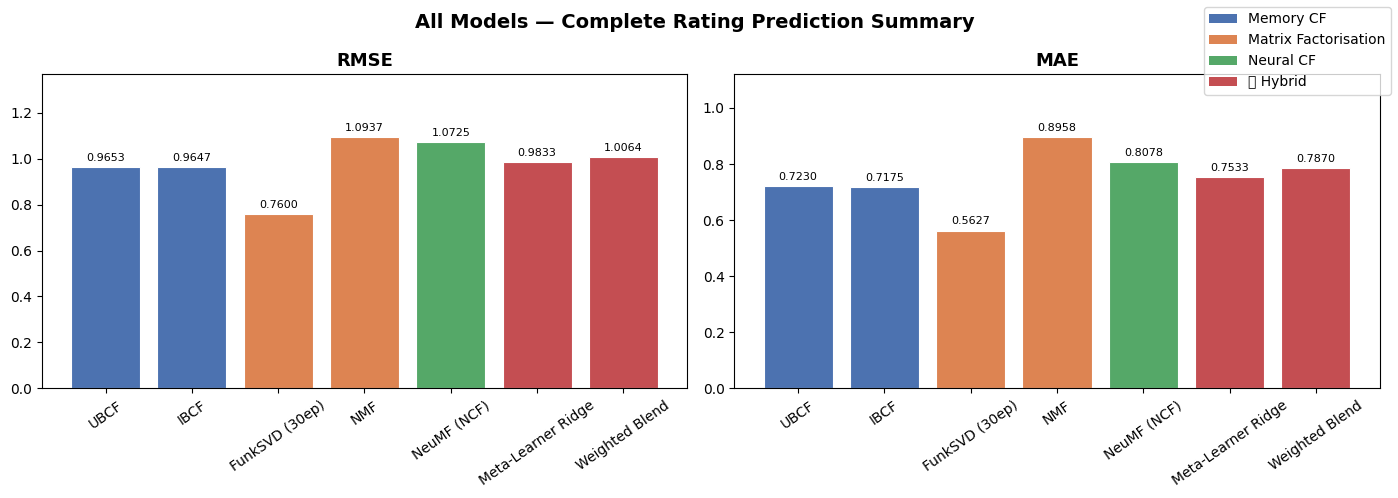

In [11]:

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load individual method results from earlier notebooks
with open(MODELS / 'cf_eval_metrics.pkl',  'rb') as f: cf_m  = pickle.load(f)
with open(MODELS / 'mf_eval_metrics.pkl',  'rb') as f: mf_m  = pickle.load(f)
with open(MODELS / 'ncf_eval_metrics.pkl', 'rb') as f: ncf_m = pickle.load(f)

# cf_m keys: ubcf_rmse, ubcf_mae, ibcf_rmse, ibcf_mae  (flat)
# mf_m keys: funk_finetuned, svd_user, nmf, ...          (nested {rmse, mae})
# ncf_m keys: ncf                                         (nested {rmse, mae})

# Weighted-blend RMSE/MAE (evaluate on meta_sample for comparability)
# Note: popularity (bayesian_score) is a ranking signal, not a rating predictor.
# For RMSE, blend only FunkSVD and NCF rating predictions with re-normalised weights.
BLEND_W_FUNK = 0.45 / (0.45 + 0.30)   # 0.60 — share of FunkSVD after dropping popularity
BLEND_W_NCF  = 0.30 / (0.45 + 0.30)   # 0.40 — share of NCF after dropping popularity

blend_preds = []
for i in range(len(meta_sample)):
    f_pred = float(np.clip(X_meta[i, 0], 0.5, 5.0))
    n_pred = float(np.clip(X_meta[i, 1], 0.5, 5.0))
    r_true = float(meta_sample.iloc[i]['rating'])
    blend_pred_r = float(np.clip(BLEND_W_FUNK*f_pred + BLEND_W_NCF*n_pred, 0.5, 5.0))
    blend_preds.append((r_true, blend_pred_r))
blend_arr = np.array(blend_preds)
blend_rmse = float(np.sqrt(np.mean((blend_arr[:,0] - blend_arr[:,1])**2)))
blend_mae  = float(np.mean(np.abs(blend_arr[:,0] - blend_arr[:,1])))

# Summary table
summary = pd.DataFrame([
    {'Method': 'UBCF',              'RMSE': cf_m['ubcf_rmse'],               'MAE': cf_m['ubcf_mae'],               'Type': 'Memory CF'},
    {'Method': 'IBCF',              'RMSE': cf_m['ibcf_rmse'],               'MAE': cf_m['ibcf_mae'],               'Type': 'Memory CF'},
    {'Method': 'FunkSVD (30ep)',     'RMSE': mf_m['funk_finetuned']['rmse'],  'MAE': mf_m['funk_finetuned']['mae'],  'Type': 'Matrix Factorisation'},
    {'Method': 'NMF',               'RMSE': mf_m['nmf']['rmse'],             'MAE': mf_m['nmf']['mae'],             'Type': 'Matrix Factorisation'},
    {'Method': 'NeuMF (NCF)',        'RMSE': ncf_m['ncf']['rmse'],            'MAE': ncf_m['ncf']['mae'],            'Type': 'Neural CF'},
    {'Method': 'Meta-Learner Ridge', 'RMSE': meta_rmse,                       'MAE': meta_mae,                       'Type': '⭐ Hybrid'},
    {'Method': 'Weighted Blend',     'RMSE': blend_rmse,                      'MAE': blend_mae,                      'Type': '⭐ Hybrid'},
])
print(summary.sort_values('RMSE').to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'Memory CF': '#4C72B0', 'Matrix Factorisation': '#DD8452',
           'Neural CF': '#55A868', '⭐ Hybrid': '#C44E52'}
colors = [palette[t] for t in summary['Type']]
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(summary['Method'], summary[metric], color=colors,
                  edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_ylim(0, summary[metric].max() * 1.25)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
legend_elems = [Patch(facecolor=v, label=k) for k, v in palette.items()]
fig.legend(handles=legend_elems, loc='upper right', framealpha=0.8)
plt.suptitle('All Models — Complete Rating Prediction Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS / 'hybrid_final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Final Hybrid Recommender Function

Unified entry point: accepts a `user_id` and optional `seed_title`, routes automatically via the switching strategy (best cold-start handling).

In [12]:
def recommend(user_id: int,
              n_recs: int = 10,
              seed_title: str | None = None) -> pd.DataFrame:
    """
    Primary recommendation function for the project.

    Uses the switching hybrid strategy:
    - Warm users (≥20 ratings): FunkSVD-led blend
    - Cold users (< 5 ratings): popularity + content-based
    - Seed title: boosts content-based similarity for all users

    Parameters
    ----------
    user_id     : MovieLens userId (use -1 for new/anonymous users)
    n_recs      : number of movies to recommend
    seed_title  : if provided, recommendations are biased toward this movie's style

    Returns
    -------
    DataFrame with columns: title, hybrid_score, funksvd_score, ncf_score, pop_score
    """
    return switching_recommend(user_id, n_recs=n_recs, seed_title=seed_title)

# ── Examples ──────────────────────────────────────────────────────────────
print("=" * 65)
print("Example 1: Warm user — personalised recommendations")
print("=" * 65)
print(recommend(demo_user).to_string(index=False))

print("\n" + "=" * 65)
print("Example 2: Seed-title — 'Inception' style recs for same user")
print("=" * 65)
print(recommend(demo_user, seed_title='Inception').to_string(index=False))

print("\n" + "=" * 65)
print("Example 3: Cold-start (new user ID = -1), no seed title")
print("=" * 65)
print(recommend(-1).to_string(index=False))

print("\n" + "=" * 65)
print("Example 4: Cold-start with seed title — 'The Dark Knight'")
print("=" * 65)
print(recommend(-1, seed_title='The Dark Knight').to_string(index=False))

Example 1: Warm user — personalised recommendations
        strategy                                             title  hybrid_score  funksvd_score  ncf_score  pop_score
warm-start blend                          The Shawshank Redemption        1.0000         1.0000     1.0000     1.0000
warm-start blend                                  Schindler's List        0.8614         0.8762     0.9386     0.7509
warm-start blend                                     The Godfather        0.8488         0.7637     0.8771     0.9170
warm-start blend     The Lord of the Rings: The Return of the King        0.8244         0.8960     0.8141     0.7510
warm-start blend                                   The Dark Knight        0.8020         0.7941     0.7834     0.8340
warm-start blend The Lord of the Rings: The Fellowship of the Ring        0.7861         0.8566     0.8142     0.6679
warm-start blend             The Lord of the Rings: The Two Towers        0.7537         0.8593     0.7888     0.5849
warm

## 9. Save Hybrid Artefacts

In [13]:
import joblib

# Save meta-learner Ridge model
joblib.dump(meta_model, MODELS / 'hybrid_meta_learner.pkl')

# Save hybrid eval summary
hybrid_eval = {
    'weighted_blend': {'rmse': blend_rmse, 'mae': blend_mae},
    'meta_learner':   {'rmse': meta_rmse,  'mae': meta_mae},
    'weights':        DEFAULT_WEIGHTS,
}
with open(MODELS / 'hybrid_eval_metrics.pkl', 'wb') as f:
    pickle.dump(hybrid_eval, f)

print("Hybrid artefacts saved:")
for fname in ['hybrid_meta_learner.pkl', 'hybrid_eval_metrics.pkl',
              'hybrid_final_comparison.png']:
    p = MODELS / fname
    if p.exists():
        print(f"  {fname:<40}  {p.stat().st_size/1024:.1f} KB")

print("\nOK NB09 complete — hybrid recommender ready for backend integration.")

Hybrid artefacts saved:
  hybrid_meta_learner.pkl                   0.5 KB
  hybrid_eval_metrics.pkl                   0.2 KB
  hybrid_final_comparison.png               61.3 KB

OK NB09 complete — hybrid recommender ready for backend integration.
